<a href="https://colab.research.google.com/github/bagadevaishnavi760-collab/Marketing_agency_customer-churn-prediction/blob/main/Marketing_agency_Customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Marketing Agency Customer Churn





---




# Content

---


The data is saved as customer_churn.csv. Here are the fields and their definitions:

Name : Name of the latest contact at Company

Age: Customer Age

Total_Purchase: Total Ads Purchased

Account_Manager: Binary 0=No manager, 1= Account manager assigned

Years: Totaly Years as a customer

Num_sites: Number of websites that use the service.

Onboard_date: Date that the name of the latest contact was onboarded

Location: Client HQ Address

Company: Name of Client Company

# Import Libraries

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,balanced_accuracy_score,classification_report,
    confusion_matrix,precision_score,roc_auc_score,RocCurveDisplay,
    recall_score,f1_score
)


# Upload the Dataset

In [122]:
df = pd.read_csv("/content/customer_churn.csv",encoding="utf-8-sig")

In [123]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


# Data Preprocessing

In [124]:
df.shape

(900, 10)

In [125]:
df.columns.tolist()

['Names',
 'Age',
 'Total_Purchase',
 'Account_Manager',
 'Years',
 'Num_Sites',
 'Onboard_date',
 'Location',
 'Company',
 'Churn']

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [127]:
display(df.describe(include= "all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Names,900,899,Jennifer Wood,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,900.0,NaN,NaN,NaN,41.816667,6.12756,22.0,38.0,42.0,46.0,65.0
Total_Purchase,900.0,NaN,NaN,NaN,10062.824033,2408.644532,100.0,8497.1225,10045.87,11760.105,18026.01
Account_Manager,900.0,NaN,NaN,NaN,0.481111,0.499921,0.0,0.0,0.0,1.0,1.0
Years,900.0,NaN,NaN,NaN,5.273156,1.274449,1.0,4.45,5.215,6.11,9.15
Num_Sites,900.0,NaN,NaN,NaN,8.587778,1.764836,3.0,7.0,8.0,10.0,14.0
Onboard_date,900,900,2010-09-25 12:16:08,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,900,900,"27252 Olivia Burgs Rivasmouth, MN 80121-6348",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,900,873,Anderson Group,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,900.0,NaN,NaN,NaN,0.166667,0.372885,0.0,0.0,0.0,0.0,1.0


# Check for missing values

In [128]:
df.isnull().sum()

,0
Names,0
Age,0
Total_Purchase,0
Account_Manager,0
Years,0
Num_Sites,0
Onboard_date,0
Location,0
Company,0
Churn,0


no missing or null value found

In [129]:
df.nunique()

,0
Names,899
Age,36
Total_Purchase,900
Account_Manager,2
Years,418
Num_Sites,12
Onboard_date,900
Location,900
Company,873
Churn,2


Name has 899 unique values among 900 records, so it acts like a customer identifier and provides no meaningful general pattern for predicting churn. Keeping it could make the model memorise customers and overfit.

Company: 873 unique values, so it is also almost an identifier.


Location: 900 unique full addresses.

In [130]:
df.drop(columns=["Names","Company","Location"],inplace=True)

Extracting useful features from Onboard_date and then dropping it
`

In [131]:
df["Onboard_date"] = pd.to_datetime(
    df["Onboard_date"],
    errors="coerce"
)

df["Onboard_Year"] = df["Onboard_date"].dt.year
df["Onboard_Month"] = df["Onboard_date"].dt.month
df["Onboard_Quarter"] = df["Onboard_date"].dt.quarter

df.drop(columns=["Onboard_date"], inplace=True)

In [132]:
df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn,Onboard_Year,Onboard_Month,Onboard_Quarter
0,42.0,11066.80,0,7.22,8.0,1,2013,8,3
1,41.0,11916.22,0,6.50,11.0,1,2013,8,3
2,38.0,12884.75,0,6.67,12.0,1,2016,6,2
3,42.0,8010.76,0,6.71,10.0,1,2014,4,2
4,37.0,9191.58,0,5.56,9.0,1,2016,1,1


Check that all columns are numerical:

In [139]:
object_columns = df.select_dtypes(include="object").columns.tolist()
print(object_columns)

[]


All the columns are therefore numerical
`

# Check for duplicate values

---



In [140]:
df.duplicated().sum()

np.int64(0)

no duplicate value found

In [141]:
print("Churn Distribution")
print(df['Churn'].value_counts())

Churn Distribution
Churn
0    750
1    150
Name: count, dtype: int64


0 = customer did not leave

1 = customer churned

this is an imbalanced binary classification problem

In [142]:
print("Churn percentage")
print(df['Churn'].value_counts(normalize = True)*100)

Churn percentage
Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64


# Visualizing the target distribution

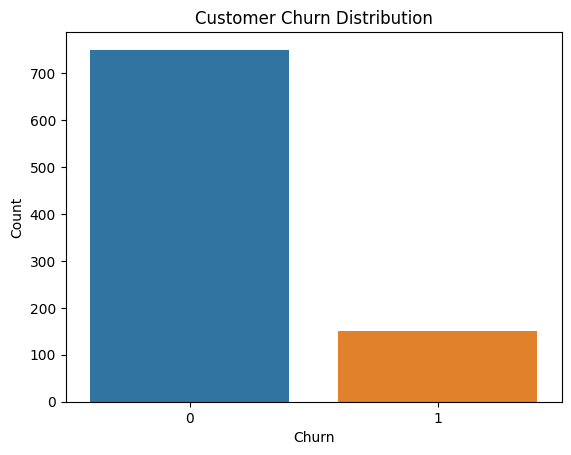

In [143]:
sns.countplot(data=df,x="Churn",hue="Churn",legend=False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The plot above clearly shows an imbalanced distribution for customer churn. The number of customers who did not churn (represented by 0) is significantly higher than those who did churn (represented by 1). This imbalance is important to note as it can affect the performance of machine learning models trained on this data.

# seperate features and target